In [1]:
#import useful python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import time

In [2]:
#load dataset
df=pd.read_parquet('new_masked_object.parquet')

In [3]:
#check dataset
df


,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF17aaafglk,22.733957,2,2.461074e+06,18.219936,1141,43.682294,0.073630,CataclyV*
1,ZTF18abavrhi,13.862530,2,2.461074e+06,16.578445,2212,244.787948,0.052932,CataclyV*
2,ZTF18acqxpid,-0.161225,2,2.461059e+06,18.902857,1094,120.643249,0.121745,CataclyV*
3,ZTF17aabsjcc,69.741185,2,2.461052e+06,17.685396,3032,67.679096,0.058235,CataclyV*
4,ZTF18abpprml,44.076774,2,2.461052e+06,19.825302,1235,91.110824,0.188079,CataclyV*
...,...,...,...,...,...,...,...,...,...
936921,ZTF18acignnq,10.637594,2,2.461084e+06,16.735125,843,298.666294,0.052518,Unknown
936922,ZTF21aageiie,-5.146635,1,2.461073e+06,15.013954,112,42.846437,0.064213,Unknown
936923,ZTF18aairqhf,16.401699,2,2.461073e+06,17.714146,3422,92.159086,0.076830,Unknown
936924,ZTF18acyxksn,-3.204930,2,2.461073e+06,15.386559,216,166.524802,0.048081,Unknown


In [4]:
#make two different arrays
cv_df = df[df["finkclass"].str.contains("CataclyV")]
unknown_df = df[df["finkclass"] == "Unknown"]

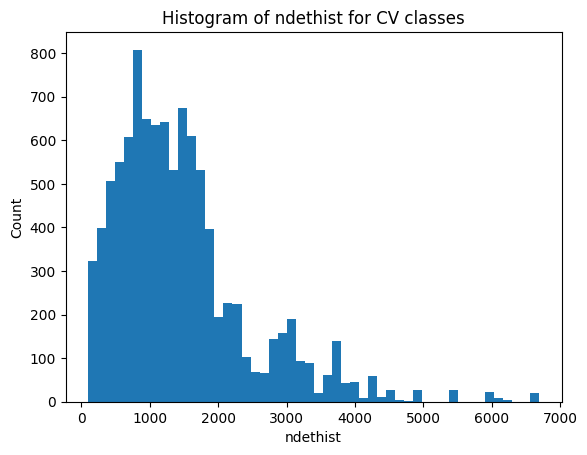

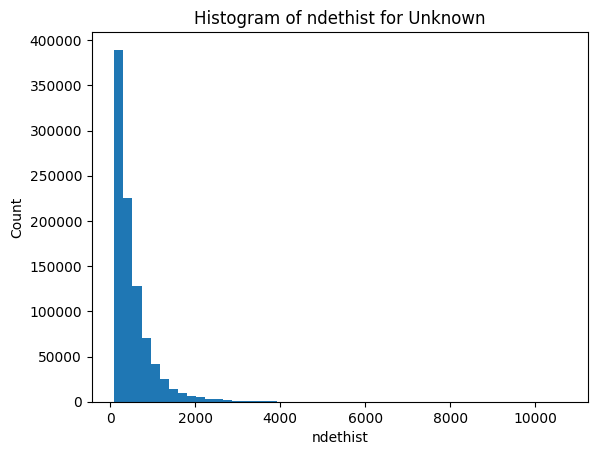

In [5]:
# CV classes histogram
plt.hist(cv_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for CV classes")
plt.xlabel("ndethist")
plt.ylabel("Count")
plt.show()

# Unknown histogram
plt.hist(unknown_df["ndethist"], bins=50)
plt.title("Histogram of ndethist for Unknown")
plt.xlabel("ndethist")
plt.ylabel("Count")
plt.show()

In [6]:
#check the elements
#df['finkclass'].unique()

In [7]:
#count of element distribution
print(df['finkclass'].value_counts())
print("Total objects:", len(df))

finkclass
Unknown                 926983
CataclyV*                 9894
CataclyV*_Candidate         49
Blazar                       0
WhiteDwarf_Candidate         0
Name: count, dtype: int64
Total objects: 936926


In [8]:
data = df.groupby("objectId", as_index=False).agg(list)

In [9]:
data.shape

(263543, 9)

In [10]:
data

,objectId,dec,fid,jd,magpsf,ndethist,ra,sigmapsf,finkclass
0,ZTF17aaaaaao,[45.430759],[2],[2461054.6163773],[18.84351348876953],[673],[63.9896447],[0.16620971262454987],[Unknown]
1,ZTF17aaaaabl,[51.4287671],[2],[2461059.6730787],[17.644813537597656],[2578],[69.9260651],[0.042603861540555954],[Unknown]
2,ZTF17aaaaaes,[47.3956061],[2],[2461053.8471759],[18.916994094848633],[1714],[77.5418002],[0.11988057941198349],[Unknown]
3,ZTF17aaaaafy,"[45.2503262, 45.2502987, 45.25031, 45.2502513,...","[2, 2, 2, 2, 2, 2, 2, 2, 2]","[2461075.7216782, 2461055.7841667, 2461074.690...","[19.56412124633789, 19.62184715270996, 19.3670...","[880, 858, 873, 869, 849, 872, 871, 863, 872]","[67.1171799, 67.1172413, 67.1172402, 67.117122...","[0.1536625623703003, 0.16926050186157227, 0.11...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
4,ZTF17aaaaafz,"[45.4096531, 45.409699, 45.4096631, 45.409654,...","[1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, ...","[2461060.6384375, 2461051.8011921, 2461055.784...","[19.610416412353516, 18.52537727355957, 17.792...","[2950, 2926, 2936, 2957, 2963, 2965, 2962, 295...","[67.3091671, 67.3091481, 67.3091953, 67.309188...","[0.1247432753443718, 0.12439146637916565, 0.06...","[Unknown, Unknown, Unknown, Unknown, Unknown, ..."
...,...,...,...,...,...,...,...,...,...
263538,ZTF26aahnfbd,[15.5479036],[1],[2461095.7147569],[17.74433708190918],[816],[104.4409572],[0.11005722731351852],[Unknown]
263539,ZTF26aahnlws,[-5.9239914],[1],[2461095.7294907],[18.9563045501709],[139],[108.7912605],[0.1571178138256073],[Unknown]
263540,ZTF26aahnsph,[-19.3192024],[1],[2461095.7502315],[15.248769760131836],[108],[114.8402318],[0.08236127346754074],[Unknown]
263541,ZTF26aahoxfv,[-19.0463413],[2],[2461095.7915046],[20.121084213256836],[104],[139.4015478],[0.19747285544872284],[Unknown]


In [11]:
#count of element distribution
print(data['finkclass'].value_counts())
print("Total objects:", len(data))

finkclass
[Unknown]                                                                                                                                                                                                                                                        127690
[Unknown, Unknown]                                                                                                                                                                                                                                                41826
[Unknown, Unknown, Unknown]                                                                                                                                                                                                                                       22134
[Unknown, Unknown, Unknown, Unknown]                                                                                                                                                                  

In [12]:
#check all unknown elements
unknown_df = data[data["finkclass"].apply(lambda x: all(v == "Unknown" for v in x))]

In [13]:
print("Pure Unknown objects:", len(unknown_df))

Pure Unknown objects: 262400


In [14]:
#check inputs with all cataclysemic variable data
cv_df = data[data["finkclass"].apply(lambda x: all("CataclyV*" in v for v in x))]

In [15]:
print("CVs:", len(cv_df))

CVs: 987


In [16]:
#check inputs with all cataclysemic variable candidate data
cv_df_1 = data[data["finkclass"].apply(lambda x: all("CataclyV*_Candidate" in v for v in x))]

In [17]:
print("CVs:", len(cv_df_1))

CVs: 3
